# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import os
import shutil
from pprint import pprint
from typing import cast

from tqdm.auto import tqdm

tqdm.pandas()
os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

In [4]:
import torch
from sentence_transformers import SentenceTransformer

from mllm_shap.connectors import LiquidAudio
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter

device = (
    torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

/Users/pawelp/Desktop/education/pw/bachelor/MLLM-Shap/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: mps


In [5]:
import gc
import io
import soundfile as sf
from experiments.constants import LIBRISPEECH_ASR__CONFIG
from datasets import load_dataset as hf_load_dataset
from huggingface_hub import list_repo_files
from experiments.io import save_json, save_parquet
from experiments.languages import LanguageClassifier
from experiments.nlp import split_into_sentences

In [6]:
# Target final dataset size
NUM_SAMPLES: int = 1000

language_classifier = LanguageClassifier()

In [29]:
def get_sample_df(df_to_sample: pd.DataFrame) -> pd.DataFrame:
    """
    For each dataset, get a sample with the longest text (in sentences).

    Args:
        df_to_sample: The DataFrame to sample from with 'datasets' and 'sentences' columns.
    Returns:
        A DataFrame containing one sample per dataset with the longest text.
    """
    return (
        df_to_sample.explode("datasets")
        .groupby("datasets", group_keys=False)
        .apply(
            lambda g: g.loc[g["sentences"].apply(len).idxmax()], include_groups=False
        )
        .sort_index()
        .reset_index()[["datasets", "sentences"]]
    )


def get_df_stats(
    df_to_analyze: pd.DataFrame, include_audio_: bool = True
) -> dict[str, float]:
    """
    Get statistics for the entire DataFrame.

    Args:
        df_to_analyze: The DataFrame to analyze with a 'prompt' and 'sentences' columns.
        include_audio_: Whether to include audio duration statistics.
    Returns:
        A dict containing the statistics.
    """
    characters__num = df_to_analyze["prompt"].apply(len)
    sentences__num = df_to_analyze["sentences"].apply(len)
    unique_entries = df_to_analyze["prompt"].nunique()

    stats = {
        "rows__num": len(df_to_analyze),
        "characters__num": round(characters__num.sum().item(), 2),
        "avg_characters__num": round(characters__num.mean().item(), 2),
        "total_sentences__num": round(sentences__num.sum().item(), 2),
        "avg_sentences__num": round(sentences__num.mean().item(), 2),
        "min_sentences__num": sentences__num.min().item(),
        "unique_entries__num": unique_entries,
        "unique_entries__pct": round(unique_entries / len(df_to_analyze) * 100, 2),
    }

    if include_audio_:
        for name in ("female", "male", "original"):
            col = f"audio__{name}__duration"
            if col in df_to_analyze.columns:
                durations = df_to_analyze[col].apply(
                    lambda x: sum(x) if isinstance(x, list) else x
                )
                stats[f"audio__{name}__duration__average"] = round(
                    durations.mean().item(), 2
                )
                stats[f"audio__{name}__duration__total"] = round(
                    durations.sum().item(), 2
                )

    return stats


def get_df_stats__by_source(df_to_analyze: pd.DataFrame) -> pd.DataFrame:
    """
    Get statistics grouped by source dataset.

    Args:
        df_to_analyze: The DataFrame to analyze with 'datasets', 'prompt', and 'sentences__num' columns.
    Returns:
        A DataFrame containing the statistics grouped by 'datasets'.
    """
    return (
        df_to_analyze.explode("datasets")
        .groupby("datasets")
        .agg(
            num_rows=("prompt", "count"),
            total_characters=("prompt", lambda x: x.str.len().sum()),
            avg_num_characters=("prompt", lambda x: x.str.len().mean()),
            avg_num_sentences=("sentences__num", "mean"),
            total_sentences=("sentences__num", "sum"),
        )
        .reset_index()
        .sort_values("datasets")
    )

In [8]:
model_for_tokens = LiquidAudio(
    device=device, history_tracking_mode=ModelHistoryTrackingMode.TEXT
)

I0429 19:04:52.626353 1114947 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

W0429 19:04:54.258000 64916 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


# Text dataset preparation and EDA

## Preprocessing

### Dataset preparation

Use RAM-optimized text-first loading from LibriSpeech ASR (`clean`) with multiple splits. Audio is attached only after final sampling, then normalized to `audio__original` as `list[bytes]` with `audio__original__duration` as `list[float]`.

In [9]:
dt: list[tuple[str, str, str]] = []
DATASET_LABEL = "LibriSpeech-ASR-clean"
TARGET_SPLITS = ("train.100", "train.360", "dev", "test")
LOADER_VERSION = "clean_multi_split_text_first_v5"
print(f"Loader: {LOADER_VERSION}")

repo_files = list_repo_files(
    repo_id=LIBRISPEECH_ASR__CONFIG.dataset_name,
    repo_type="dataset",
    revision=LIBRISPEECH_ASR__CONFIG.revision,
)

available_split_dirs = sorted(
    {
        f.split("/")[1]
        for f in repo_files
        if f.startswith("clean/") and f.endswith(".parquet") and len(f.split("/")) >= 3
    }
)
print("Available clean split dirs:", available_split_dirs)

# Handle naming variants used on HF (dev/dev.clean, test/test.clean)
split_aliases = {
    "dev": ("dev", "dev.clean"),
    "test": ("test", "test.clean"),
}

resolved_splits: list[str] = []
for split_name in TARGET_SPLITS:
    candidates = split_aliases.get(split_name, (split_name,))
    resolved = next((c for c in candidates if c in available_split_dirs), None)
    if resolved is None:
        print(f"Skipping missing split: {split_name} (candidates: {candidates})")
        continue
    resolved_splits.append(resolved)

if not resolved_splits:
    raise ValueError("No target clean splits resolved. Check dataset layout.")

print("Resolved splits:", resolved_splits)

for split_name in resolved_splits:
    prefix = f"clean/{split_name}/"
    split_files = sorted(
        f for f in repo_files if f.startswith(prefix) and f.endswith(".parquet")
    )
    if not split_files:
        print(f"Skipping empty split prefix: {prefix}")
        continue

    print(f"Loading text-only pool from {prefix} ({len(split_files)} shards)")
    data_files = [
        f"hf://datasets/{LIBRISPEECH_ASR__CONFIG.dataset_name}@{LIBRISPEECH_ASR__CONFIG.revision}/{f}"
        for f in split_files
    ]

    split_ds = hf_load_dataset(
        "parquet",
        data_files={"train": data_files},
        split="train",
        cache_dir=str(LIBRISPEECH_ASR__CONFIG.cache_dir),
    )

    if "audio" in split_ds.column_names:
        split_ds = split_ds.remove_columns(["audio"])

    dt.extend(
        [
            cast(tuple[str, str, str], [entry["text"], DATASET_LABEL, split_name])
            for entry in split_ds
        ]
    )

    del split_ds
    gc.collect()

df = pd.DataFrame(dt, columns=["prompt", "dataset", "split"])
del dt
print(f"Text pool rows loaded: {len(df)}")

Loader: clean_multi_split_text_first_v5
Available clean split dirs: ['test', 'train.100', 'train.360', 'validation']
Skipping missing split: dev (candidates: ('dev', 'dev.clean'))
Resolved splits: ['train.100', 'train.360', 'test']
Loading text-only pool from clean/train.100/ (14 shards)
Loading text-only pool from clean/train.360/ (48 shards)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Loading text-only pool from clean/test/ (1 shards)


Generating train split: 0 examples [00:00, ? examples/s]

Text pool rows loaded: 135173


In [16]:
def to_audio_bytes_and_duration(audio_entry: dict) -> tuple[list[bytes], list[float]]:
    arr = np.asarray(audio_entry["array"], dtype=np.float32)
    sr = int(audio_entry["sampling_rate"])

    if arr.ndim > 1:
        arr = arr.mean(axis=1)

    buf = io.BytesIO()
    sf.write(buf, arr, sr, format="WAV", subtype="PCM_16")
    audio_bytes = buf.getvalue()
    duration = float(len(arr) / sr) if sr > 0 else 0.0
    return [audio_bytes], [duration]

Split prompt into sentences and check if they are English.

In [11]:
df["sentences"] = df["prompt"].progress_apply(split_into_sentences)
df["sentences__num"] = df["sentences"].apply(len)
df["is_english"] = df["prompt"].progress_apply(language_classifier.is_english)

  0%|          | 0/135173 [00:00<?, ?it/s]

  0%|          | 0/135173 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [12]:
pprint(get_df_stats(df, include_audio_=False))

{'avg_characters__num': 182.53,
 'avg_sentences__num': 1.0,
 'characters__num': 24672615,
 'min_sentences__num': 1,
 'rows__num': 135173,
 'total_sentences__num': 135173,
 'unique_entries__num': 135117,
 'unique_entries__pct': 99.96}


In [13]:
non_english_entries: pd.Series = df[~df["is_english"]]["prompt"]
pprint(sorted(non_english_entries.unique()))

['A AS IN MAY E AS IN MET U AS IN USE A',
 'A BLAKENEY HAD DIED ON BOSWORTH FIELD',
 'A GREAT BOY WHO IS ALMOST SIX',
 'A GREAT SAINT SAINT FRANCIS XAVIER',
 'A HURON WAR CHIEF NAMED ETIENNE',
 'A LONG PAUSE NURSE ROSEMARY GRAY WAITED',
 'A SPECIES TO BE DESTROYED',
 'A SUBTLE FIRE FLOWED THROUGH MY VEINS',
 'A WASTE A WASTE A WASTE MY TWEMLOW',
 'ABEMY REPLICA',
 'ABUSE NOT BY WORD HIM WHOM THOU HAST TO PUNISH IN DEED',
 'AGAIN AGAIN',
 'ALAMEDA ANTOINETTE MONOPLANE PERIQUE BLERIOT MONOPLANE LOI TONG SANTOS '
 'DUMONT MONOPLANE WENDELL CURTIS BIPLANE DE TROMP FARMAN BIPLANE',
 'ALAS SIGHED SHE',
 'AMONG FRIENDS BUT IT WAS A MISTAKE',
 "AN DE FIRE DIED DOWN AN DE WIND BLEWED MO'NFUL OUTSIDE",
 "AN DE WIMMINS DEY LET OUT A TURR'BLE SCREECH KASE DEY SEED TWA'N'T NUTTIN "
 'BUT A BIG OWL SETTIN DAR BLINKIN',
 'AN ESCAPE HAD BEEN PLANNED',
 "AN I DON'T LIKE SALADS",
 'AN UNUSUAL HONOR',
 'AN WE SAY HOLD ON AS LONGS U KIN',
 'ANGOR PAIN PAINFUL TO HEAR',
 'ANTONIA SEEMED FRIGHTENED AT FIRST

In [14]:
print(pd.Series(non_english_entries).value_counts())
del non_english_entries

prompt
MONDAY                                  2
A GREAT SAINT SAINT FRANCIS XAVIER      2
AS AUGUSTINE SAYS                       2
JULY THIRTIETH EIGHTEEN THIRTY EIGHT    1
RIMER                                   1
                                       ..
DEAR GOOD RENEE                         1
EVEN UNTO BONDS AS AN EVIL DOER         1
DOMESTICK GREATNESS UNATTAINABLE        1
I ANSWERED AS BEST I COULD              1
AY ME                                   1
Name: count, Length: 419, dtype: int64


Deduplicate by prompt. Because LibriSpeech can contain repeated transcripts across splits/speakers,
we collapse duplicates and keep the union of source dataset labels.
For `audio__original` we retain the first occurrence, matching the original single-sentence deduplication strategy.

In [15]:
df = (
    df.groupby(["prompt"])
    .agg(
        {
            "dataset": lambda x: sorted(set(x)),
            "sentences": "first",
            "sentences__num": "first",
        }
    )
    .reset_index()
    .rename(columns={"dataset": "datasets"})
)

# Single Sentence Dataset (1 000 samples)

A dataset containing single-sentence scenarios with source audio and duration. Audio is attached only after final sampling for RAM efficiency:
`audio__original` (as `list[bytes]`) and `audio__original__duration` (as `list[float]`).

## 1 · Filter to single-sentence entries

In [16]:
single_sentence__df: pd.DataFrame = df[df["sentences__num"] == 1].copy()
print(
    f"Unique single-sentence entries before quality filtering: {len(single_sentence__df)}"
)

Unique single-sentence entries before quality filtering: 135117


In [17]:
single_sentence__df.head(3)

,prompt,datasets,sentences,sentences__num
0,A AS IN MAY E AS IN MET U AS IN USE A,[LibriSpeech-ASR-clean],[A AS IN MAY E AS IN MET U AS IN USE A],1
1,A BABY PRINCESS WAS BORN WHOM SHE NAMED DESIRE...,[LibriSpeech-ASR-clean],[A BABY PRINCESS WAS BORN WHOM SHE NAMED DESIR...,1
2,A BADGE AND TWO SMALL STRAP BUTTONS ALL THESE ...,[LibriSpeech-ASR-clean],[A BADGE AND TWO SMALL STRAP BUTTONS ALL THESE...,1


In [18]:
pprint(single_sentence__df["datasets"].apply(len).value_counts().sort_index())

datasets
1    135117
Name: count, dtype: int64


## 2 · NLP quality & interestingness filter

We use `sentence-transformers` (`all-MiniLM-L6-v2`) to compute dense embeddings for every
candidate sentence and then:

1. **Hard rule-based pre-filter** — discard trivially short / low-information entries.
2. **Embedding-based diversity / interestingness score** — project embeddings onto a
   "general-purpose query" anchor vector and keep the top-scoring fraction.  This pushes
   out near-empty or degenerate sentences that happen to pass the hard rules.
3. **Semantic deduplication** — greedy nearest-neighbour pass with a cosine-similarity
   threshold; much more effective than exact tuple comparison because it catches
   paraphrases and minor rewrites.

The NLP filtering happens **before** any token-count or stratified sampling so that
downstream steps work on a high-quality pool.

In [19]:
st_model = SentenceTransformer("all-MiniLM-L6-v2", device=str(device))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [20]:
def is_interesting_rule_based(text: str) -> bool:
    """Reject clearly low-quality sentences before embedding."""
    text = text.strip()
    words = text.split()
    # Too short: fewer than 4 words is rarely an interesting standalone query
    if len(words) < 4:
        return False
    # Too long for single-sentence (sanity guard)
    if len(text) > 300:
        return False
    # Starts with a URL or code fragment
    if text.startswith(("http", "www", "<", "{", "[")):
        return False
    # Mostly numeric / punctuation
    alpha_ratio = sum(c.isalpha() for c in text) / max(len(text), 1)
    if alpha_ratio < 0.55:
        return False
    return True


before = len(single_sentence__df)
single_sentence__df = (
    single_sentence__df[single_sentence__df["prompt"].apply(is_interesting_rule_based)]
    .copy()
    .reset_index(drop=True)
)
print(
    f"After rule-based filter: {len(single_sentence__df)} / {before} entries retained"
)

After rule-based filter: 134160 / 135117 entries retained


In [21]:
texts = single_sentence__df["prompt"].tolist()
embeddings = st_model.encode(
    texts,
    batch_size=256,
    show_progress_bar=True,
    normalize_embeddings=True,  # L2-normalise → cosine sim = dot product
    convert_to_numpy=True,
)
print(f"Embeddings shape: {embeddings.shape}")

Batches:   0%|          | 0/525 [00:00<?, ?it/s]

Embeddings shape: (134160, 384)


In [22]:
# ── Interestingness score via anchor projection ───────────────────────────────
#
# We define a set of "prototype" sentences that represent a range of interesting
# voice-assistant queries and compute how similar each candidate is to this
# prototype centroid. Sentences that are close in embedding space to these
# prototypes are retained; outliers / trivial fillers are discarded.
#
# This is intentionally lightweight and avoids any external API calls.

ANCHOR_SENTENCES = [
    "What is the capital of France?",
    "Can you help me write a short story about a robot?",
    "Explain the concept of machine learning in simple terms.",
    "How do I bake a chocolate cake from scratch?",
    "Tell me a joke about scientists.",
    "What are the main causes of climate change?",
    "Summarise the plot of Romeo and Juliet.",
    "How does the stock market work?",
    "Give me a recipe for a healthy breakfast.",
    "What programming language should I learn first?",
]

anchor_embeddings = st_model.encode(
    ANCHOR_SENTENCES,
    batch_size=32,
    normalize_embeddings=True,
    convert_to_numpy=True,
)
anchor_centroid = anchor_embeddings.mean(axis=0)
anchor_centroid /= np.linalg.norm(anchor_centroid)  # re-normalise

# Cosine similarity (dot product because embeddings are L2-normalised)
interestingness_scores = embeddings @ anchor_centroid

single_sentence__df["interestingness_score"] = interestingness_scores

# Retain the top 80 % by interestingness to cut noise while keeping a large pool
INTERESTINGNESS_PERCENTILE = 20  # drop the bottom N %
threshold = np.percentile(interestingness_scores, INTERESTINGNESS_PERCENTILE)
mask = interestingness_scores >= threshold

before = len(single_sentence__df)
single_sentence__df = single_sentence__df[mask].copy().reset_index(drop=True)
embeddings = embeddings[mask]
print(
    f"After interestingness filter (bottom {INTERESTINGNESS_PERCENTILE}% removed): "
    f"{len(single_sentence__df)} / {before} entries retained"
)

After interestingness filter (bottom 20% removed): 107328 / 134160 entries retained


In [23]:
# ── Semantic deduplication (greedy cosine-similarity pass) ────────────────────
#
# Unlike exact tuple comparison, this removes near-paraphrases and minor rewrites.
# We sort candidates by interestingness (descending) so the "best" representative
# of any cluster is always kept when a near-duplicate is encountered.

SIMILARITY_THRESHOLD = 0.92  # sentences more similar than this are near-duplicates


def semantic_dedup(
    embs: np.ndarray,
    threshold: float,
    scores: np.ndarray,
) -> np.ndarray:
    """
    Greedy semantic deduplication.

    Parameters
    ----------
    embs      : (N, D) float32 array of L2-normalised embeddings.
    threshold : cosine similarity above which two sentences are considered duplicates.
    scores    : (N,) interestingness scores used to sort candidates before the pass.

    Returns
    -------
    kept_indices : sorted original indices of the surviving entries.
    """
    # Process highest-scoring first so we always keep the best representative
    order = np.argsort(-scores)
    kept = []
    kept_embs = []

    for idx in tqdm(order, desc="semantic dedup"):
        emb = embs[idx]  # shape (D,)
        if kept_embs:
            # Batch dot product against all already-kept embeddings
            sims = np.array(kept_embs) @ emb  # shape (K,)
            if sims.max() >= threshold:
                continue  # near-duplicate of something already kept
        kept.append(idx)
        kept_embs.append(emb)

    return np.sort(kept)


kept_indices = semantic_dedup(
    embs=embeddings,
    threshold=SIMILARITY_THRESHOLD,
    scores=interestingness_scores[mask],
)

before = len(single_sentence__df)
single_sentence__df = (
    single_sentence__df.iloc[kept_indices].copy().reset_index(drop=True)
)
embeddings = embeddings[kept_indices]
print(
    f"After semantic dedup (threshold={SIMILARITY_THRESHOLD}): "
    f"{len(single_sentence__df)} / {before} entries retained"
)

semantic dedup:   0%|          | 0/107328 [00:00<?, ?it/s]

After semantic dedup (threshold=0.92): 107232 / 107328 entries retained


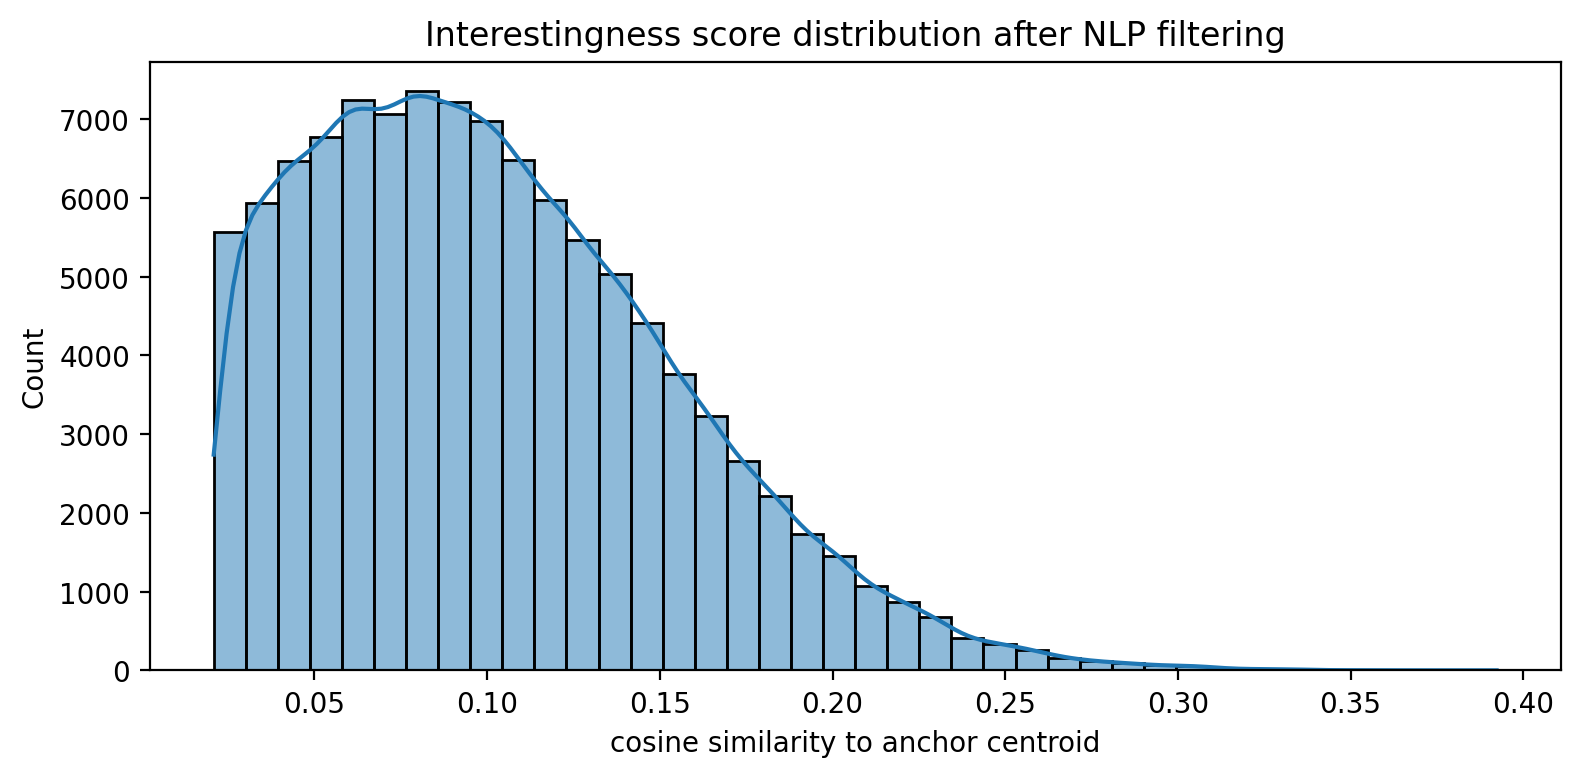

In [24]:
# Quick sanity check: score distribution after filtering
plt.figure(figsize=(8, 4))
sns.histplot(single_sentence__df["interestingness_score"], bins=40, kde=True)
plt.title("Interestingness score distribution after NLP filtering")
plt.xlabel("cosine similarity to anchor centroid")
plt.tight_layout()
plt.show()

## 3 · Token-count filter

Count explainability tokens (mask sum) and keep only entries with ≤ 10 tokens, consistent with the original single sentence budget.

In [25]:
def compute_token_counts(
    input_df: pd.DataFrame, text_column: str = "prompt"
) -> list[int]:
    """Compute number of tokens (mask sum) for each text entry."""
    counts = []
    for text in tqdm(input_df[text_column].tolist(), desc="token counting"):
        chat_local = model_for_tokens.get_new_chat(
            system_roles_setup=SystemRolesSetup.SYSTEM_ASSISTANT,
            token_filter=ExcludePunctuationTokensFilter(),
        )
        chat_local.new_turn(Role.SYSTEM)
        chat_local.add_text("You are a helpful assistant.")
        chat_local.end_turn()
        chat_local.new_turn(Role.USER)
        chat_local.add_text(text)
        chat_local.end_turn()
        tok = int(chat_local.shap_values_mask.sum().item())
        counts.append(tok)
    return counts

In [26]:
MAX_TOKEN_COUNT = 10

single_sentence__df["token_count"] = compute_token_counts(
    single_sentence__df, text_column="prompt"
)
print(f"Computed token counts for {len(single_sentence__df)} entries.")

candidates = (
    single_sentence__df[single_sentence__df["token_count"] <= MAX_TOKEN_COUNT]
    .copy()
    .reset_index(drop=True)
)
print(f"Candidates with token_count <= {MAX_TOKEN_COUNT}: {len(candidates)}")

token counting:   0%|          | 0/107232 [00:00<?, ?it/s]

Computed token counts for 107232 entries.
Candidates with token_count <= 10: 448


## 4 · Stratified sampling to 1 000 samples

We sample jointly on `datasets__combined` × `token_count` to preserve both
source distribution and token-count diversity.

In [27]:
candidates["datasets__combined"] = candidates["datasets"].apply(lambda x: " ".join(x))

In [28]:
def stratified_sample(
    pool: pd.DataFrame,
    n_target: int,
    strat_col: str = "token_count",
    random_state: int = 0,
) -> pd.DataFrame:
    """
    Stratified sample of n_target rows from pool, balanced across strat_col.

    If the pool is smaller than n_target, all rows are returned.
    Remaining quota is filled from the un-sampled portion if some groups are too small.
    """
    if len(pool) <= n_target:
        return pool.reset_index(drop=True)

    groups = sorted(pool[strat_col].unique())
    base_n = n_target // len(groups)
    remainder = n_target % len(groups)
    parts = []
    selected_idx: list[int] = []

    for i, g in enumerate(groups):
        n = base_n + (1 if i < remainder else 0)
        group_df = pool[pool[strat_col] == g]
        take = min(n, len(group_df))
        if take > 0:
            samp = group_df.sample(n=take, random_state=random_state)
            parts.append(samp)
            selected_idx.extend(samp.index.tolist())

    result = pd.concat(parts, ignore_index=True)

    # Fill shortfall from the remaining pool (groups that were too small)
    if len(result) < n_target:
        remaining = pool.drop(index=selected_idx)
        need = min(n_target - len(result), len(remaining))
        if need > 0:
            filler = remaining.sample(n=need, random_state=random_state)
            result = pd.concat([result, filler], ignore_index=True)

    return result.reset_index(drop=True)


single_sentence__df = stratified_sample(
    pool=candidates,
    n_target=NUM_SAMPLES,
    strat_col="token_count",
)
print(f"Final dataset size: {len(single_sentence__df)}")

Final dataset size: 448


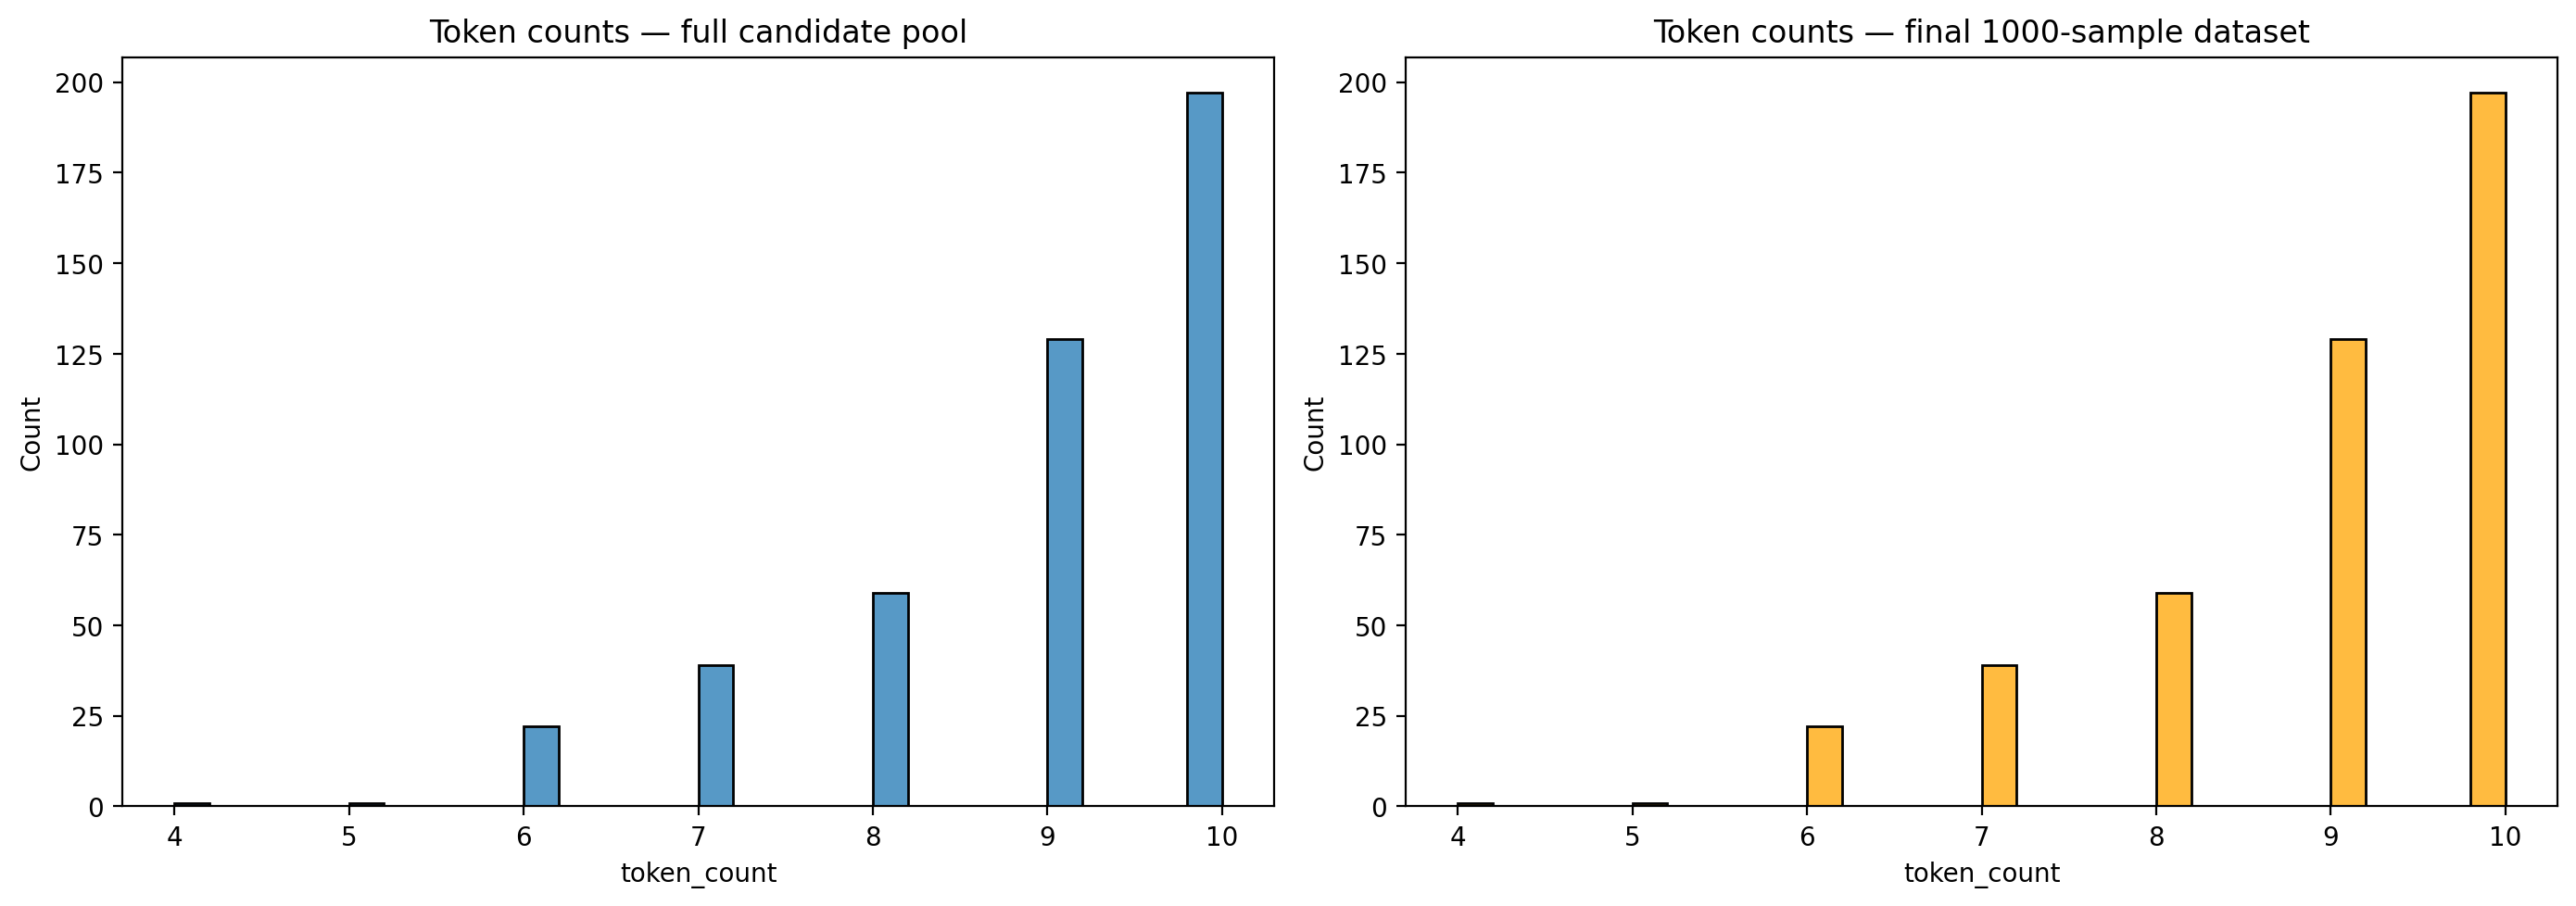

Token count summary (final dataset):
count    448.000000
mean       8.966518
std        1.206338
min        4.000000
25%        8.000000
50%        9.000000
75%       10.000000
max       10.000000
Name: token_count, dtype: float64


In [29]:
# Visualise token-count distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(candidates["token_count"], bins=30, kde=False, ax=axes[0])
axes[0].set_title("Token counts — full candidate pool")
axes[0].set_xlabel("token_count")

sns.histplot(
    single_sentence__df["token_count"], bins=30, color="orange", kde=False, ax=axes[1]
)
axes[1].set_title(f"Token counts — final {NUM_SAMPLES}-sample dataset")
axes[1].set_xlabel("token_count")

plt.tight_layout()
plt.show()

print("Token count summary (final dataset):")
print(single_sentence__df["token_count"].describe())

In [30]:
# Attach source audio only for final sampled prompts (RAM-optimized second pass)
selected_prompts = set(single_sentence__df["prompt"].tolist())
audio_lookup: dict[str, tuple[list[bytes], list[float]]] = {}

repo_files = list_repo_files(
    repo_id=LIBRISPEECH_ASR__CONFIG.dataset_name,
    repo_type="dataset",
    revision=LIBRISPEECH_ASR__CONFIG.revision,
)

available_split_dirs = sorted(
    {
        f.split("/")[1]
        for f in repo_files
        if f.startswith("clean/") and f.endswith(".parquet") and len(f.split("/")) >= 3
    }
)

split_aliases = {
    "dev": ("dev", "dev.clean"),
    "test": ("test", "test.clean"),
}
resolved_splits: list[str] = []
for split_name in TARGET_SPLITS:
    candidates = split_aliases.get(split_name, (split_name,))
    resolved = next((c for c in candidates if c in available_split_dirs), None)
    if resolved is not None:
        resolved_splits.append(resolved)

for split_name in resolved_splits:
    if len(audio_lookup) == len(selected_prompts):
        break

    prefix = f"clean/{split_name}/"
    split_files = sorted(
        f for f in repo_files if f.startswith(prefix) and f.endswith(".parquet")
    )
    if not split_files:
        continue

    print(f"Attaching audio from {prefix} ({len(split_files)} shards)")
    data_files = [
        f"hf://datasets/{LIBRISPEECH_ASR__CONFIG.dataset_name}@{LIBRISPEECH_ASR__CONFIG.revision}/{f}"
        for f in split_files
    ]

    split_ds = hf_load_dataset(
        "parquet",
        data_files={"train": data_files},
        split="train",
        cache_dir=str(LIBRISPEECH_ASR__CONFIG.cache_dir),
    )

    for entry in split_ds:
        prompt = entry["text"]
        if prompt not in selected_prompts or prompt in audio_lookup:
            continue
        audio_lookup[prompt] = to_audio_bytes_and_duration(entry["audio"])
        if len(audio_lookup) == len(selected_prompts):
            break

    del split_ds
    gc.collect()

missing = selected_prompts - set(audio_lookup.keys())
if missing:
    raise ValueError(f"Missing audio for {len(missing)} sampled prompts")

single_sentence__df["audio__original"] = single_sentence__df["prompt"].map(
    lambda p: audio_lookup[p][0]
)
single_sentence__df["audio__original__duration"] = single_sentence__df["prompt"].map(
    lambda p: audio_lookup[p][1]
)

print(
    f"Attached audio for {len(audio_lookup)} / {len(selected_prompts)} sampled prompts"
)

Attaching audio from clean/train.100/ (14 shards)
Attaching audio from clean/train.360/ (48 shards)


Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/47 [00:00<?, ?it/s]

Attaching audio from clean/test/ (1 shards)
Attached audio for 448 / 448 sampled prompts


## 5 · Stats

### Dataset-level metrics

In [11]:
get_df_stats__by_source(single_sentence__df)

,datasets,num_rows,total_characters,avg_num_characters,avg_num_sentences,total_sentences
0,LibriSpeech-ASR-clean,448,10311,23.015625,1.0,448


In [30]:
pprint(get_df_stats(df, include_audio_=True))

{'audio__original__duration__average': 2.44,
 'audio__original__duration__total': 1092.5,
 'avg_characters__num': 23.02,
 'avg_sentences__num': 1.0,
 'characters__num': 10311,
 'min_sentences__num': 1,
 'rows__num': 448,
 'total_sentences__num': 448,
 'unique_entries__num': 448,
 'unique_entries__pct': 100.0}


In [33]:
tokens = single_sentence__df["token_count"]
budgets = {
    "n^2": sum(min(2**t, t**2) for t in tokens),
    "2n^2": sum(min(2**t, 2 * t**2) for t in tokens),
    "3n^2": sum(min(2**t, 3 * t**2) for t in tokens),
    "4n^2": sum(min(2**t, 4 * t**2) for t in tokens),
    "frac 0.1": sum(0.1 * 2**t for t in tokens),
    "frac 0.2": sum(0.2 * 2**t for t in tokens),
}
print(budgets)

{'n^2': 36669, '2n^2': 73128, '3n^2': 108223, '4n^2': 142148, 'frac 0.1': 28932.800000000003, 'frac 0.2': 57865.600000000006}


## 6 · Save dataset

The saved parquet contains `audio__original` (`list[bytes]`) and `audio__original__duration` (`list[float]`).

In [ ]:
# Columns to drop from the saved artefact (keep everything else, including audio__original)
COLS_TO_DROP = ["sentences__num", "datasets__combined", "interestingness_score"]
cols_present = [c for c in COLS_TO_DROP if c in single_sentence__df.columns]

single_sentence__df__to_save = single_sentence__df.drop(columns=cols_present)

# Final column order for clarity
ordered_audio_cols = ["audio__original", "audio__original__duration"]
other_cols = [
    c for c in single_sentence__df__to_save.columns if c not in ordered_audio_cols
]
single_sentence__df__to_save = single_sentence__df__to_save[
    other_cols
    + ordered_audio_cols
    + [
        c
        for c in single_sentence__df__to_save.columns
        if c not in other_cols and c not in ordered_audio_cols
    ]
]

single_sentence__df__to_save.drop(columns=["prompt"], inplace=True)

save_parquet(
    single_sentence__df__to_save,
    LIBRISPEECH_ASR__CONFIG.data_dir / "single_sentence_500.parquet",
)
print(f"Saved {len(single_sentence__df__to_save)} rows.")
print("Columns:", list(single_sentence__df__to_save.columns))

Saved 448 rows.
Columns: ['datasets', 'sentences', 'token_count', 'audio__original', 'audio__original__duration']


### Processed samples

In [36]:
sample__df: pd.DataFrame = get_sample_df(single_sentence__df)
save_json(
    sample__df,
    LIBRISPEECH_ASR__CONFIG.data_dir / "single_sentence_1k__text__sample.json",
)
sample__df.head(5)

,datasets,sentences
0,LibriSpeech-ASR-clean,[A DANGEROUS AGE WELL]


## Cleanup

In [37]:
del sample__df, single_sentence__df, single_sentence__df__to_save, candidates
del embeddings, st_model

# Final cleanup

In [38]:
shutil.rmtree(LIBRISPEECH_ASR__CONFIG.cache_dir)